In [1]:
import os
import sys
import pickle
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import inspect  
from collections import Counter

sys.path.insert(0, os.path.abspath('..'))

from train_rnn_updated import (
    MC_RNN_Dataset,  # 数据集类（已更新为返回 tensor）
    RNNConv,         # RNN 模型类
    LSTMConv,
    GRUConv,
    GaWFRNNConv,     # GaWF RNN 模型类
    network_train,  # 训练函数
)

print(inspect.signature(GaWFRNNConv))  # 应该包含 hidden_size

(num_classes, num_pos, kernel_size=3, device='cuda', dropout_rate=0.3)


In [2]:
# list cuda devices
print("Available CUDA devices:")
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

Available CUDA devices:


In [3]:
# 封装的可视化函数和保存/加载功能

def visualize_results(results, model, test_ds, test_dl,
                      use_sector=False, num_sectors=10,
                      num_vis=8, show_test_results=True,
                      predict_all_chars=False):
    """
    可视化训练结果和测试集预测
    
    Args:
        results: 训练结果字典，包含 'train_acc_char', 'val_acc_char' 等（不包含 'model'）
        model: 训练好的模型对象（单独传递）
        test_ds: 测试数据集
        test_dl: 测试数据加载器
        use_sector: 如果为 True，则可视化 sector location；否则可视化坐标
        num_sectors: sector 数量（仅在 use_sector=True 时使用）
        num_vis: 可视化的样本数量
        show_test_results: 如果为 True，则显示测试集的可视化和打印结果；否则跳过
        predict_all_chars: 如果为 True，表示使用 all-chars 模型（只预测字符，不预测位置）
    """
    # 1. 绘制训练 / 验证性能曲线
    # 自动检测实际训练的epoch数（支持早停机制）
    # 如果results中有actual_epochs字段，使用它；否则使用数组的实际长度
    if "actual_epochs" in results:
        actual_epochs = results["actual_epochs"]
    else:
        # 兼容旧版本：使用数组的实际长度（去除末尾的0值）
        # 找到最后一个非零值的位置
        train_acc = results["train_acc_char"]
        # 如果数组全为0或最后都是0，使用数组长度
        # 否则找到最后一个明显大于0的值（阈值设为1.0，避免浮点误差）
        non_zero_mask = train_acc > 1.0
        if np.any(non_zero_mask):
            actual_epochs = np.where(non_zero_mask)[0][-1] + 1
        else:
            actual_epochs = len(train_acc)

    print(f"实际训练的epoch数: {actual_epochs}")

    # 打印训练/验证的最大准确率（char/pos）
    def _safe_max(key):
        arr = results.get(key)
        if arr is None or len(arr) == 0:
            return None
        arr = np.asarray(arr)[:actual_epochs]
        if arr.size == 0:
            return None
        return float(np.nanmax(arr))

    max_train_char = _safe_max("train_acc_char")
    max_val_char = _safe_max("val_acc_char")
    if max_train_char is not None:
        print(f"Train char acc max: {max_train_char:.2f}%")
    else:
        print("Train char acc max: N/A")
    if max_val_char is not None:
        print(f"Val char acc max: {max_val_char:.2f}%")
    else:
        print("Val char acc max: N/A")

    if predict_all_chars:
        # all-chars 模式：不包含位置预测
        print("Train/Val pos metrics: N/A (all-chars mode, no position prediction)")
    else:
        max_train_pos = _safe_max("train_acc_pos")
        max_val_pos = _safe_max("val_acc_pos")
        if max_train_pos is not None:
            print(f"Train pos acc max: {max_train_pos:.2f}%")
        else:
            print("Train pos acc max: N/A")
        if max_val_pos is not None:
            print(f"Val pos acc max: {max_val_pos:.2f}%")
        else:
            print("Val pos acc max: N/A")

    plt.figure(figsize=(12, 5))

    # 字符识别准确率（只显示实际训练的epoch）
    plt.subplot(1, 2, 1)
    plt.plot(results["train_acc_char"][:actual_epochs], label="train char acc")
    plt.plot(results["val_acc_char"][:actual_epochs], label="val char acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Character accuracy")
    plt.ylim(-5, 105)  # 固定纵坐标范围为0-100
    plt.legend()

    # 位置相关指标（只显示实际训练的epoch）
    plt.subplot(1, 2, 2)
    if predict_all_chars:
        # all-chars 模式：不绘制任何位置相关的曲线
        plt.axis("off")
        plt.title("No position metrics (all-chars mode)")
    else:
        if use_sector:
            # sector 模式：显示准确率
            if "train_acc_pos" in results and "val_acc_pos" in results:
                plt.plot(results["train_acc_pos"][:actual_epochs], label="train sector acc")
                plt.plot(results["val_acc_pos"][:actual_epochs], label="val sector acc")
                plt.ylabel("Accuracy (%)")
                plt.title("Sector accuracy")
                plt.ylim(39, 102.5)  # 固定纵坐标范围为50-100
            else:
                print("Warning: train_acc_pos or val_acc_pos not found in results")
        else:
            # 坐标模式：显示 MSE
            if "train_err_pos" in results and "val_err_pos" in results:
                plt.plot(results["train_err_pos"][:actual_epochs], label="train pos MSE")
                plt.plot(results["val_err_pos"][:actual_epochs], label="val pos MSE")
                plt.ylabel("MSE (pixel^2)")
                plt.title("Position error")
            else:
                print("Warning: train_err_pos or val_err_pos not found in results")
        plt.xlabel("Epoch")
        plt.legend()

    plt.tight_layout()
    plt.show()

    # 2. 使用训练好的模型在 test set 上推理（可选）
    if not show_test_results:
        return

    # all-chars 模式的 test 可视化
    if predict_all_chars:
        # all-chars 模式：展示 frame 图片，打印 fg/bg chars 和预测结果
        mdl_eval = model
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        mdl_eval = mdl_eval.to(device)
        mdl_eval.device = device.type
        mdl_eval.eval()
        
        # 获取 max_chars 参数（从模型或数据集）
        max_chars = getattr(test_ds, 'max_chars', 10) if test_ds is not None else 10
        
        all_char_preds = []  # 存储每个样本的预测字符列表
        all_char_gts = []    # 存储每个样本的 GT 字符列表
        all_fg_chars_gt = []  # 存储每个样本的 GT fg char
        all_bg_chars_gt = []  # 存储每个样本的 GT bg chars 列表
        
        with torch.no_grad():
            for batch in test_dl:
                inputs, labels = batch
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # all-chars 模式：out_char 是 (B, T, max_chars, num_classes)
                out_char, out_pos = mdl_eval(inputs)
                
                # 取每个序列最后一帧的预测
                # out_char: (B, T, max_chars, num_classes) -> (B, max_chars, num_classes)
                frame_logits = out_char[:, -1, :, :]  # (B, max_chars, num_classes)
                frame_labels = labels[:, -1, :]  # (B, max_chars)
                
                # 对每个样本进行 greedy matching
                batch_size = frame_logits.shape[0]
                pred_probs = F.softmax(frame_logits, dim=-1)  # (B, max_chars, num_classes)
                
                for b in range(batch_size):
                    # GT: 获取有效字符（去除 -1）
                    true_chars = frame_labels[b].cpu().numpy()  # (max_chars,)
                    valid_mask = true_chars >= 0
                    valid_true_chars = true_chars[valid_mask].tolist()
                    
                    if len(valid_true_chars) == 0:
                        continue
                    
                    # 分离 fg 和 bg chars
                    fg_char_gt = int(valid_true_chars[0])  # 第一个是 fg
                    bg_chars_gt = [int(x) for x in valid_true_chars[1:]]  # 其余是 bg
                    
                    # 预测：使用 greedy matching
                    frame_probs_b = pred_probs[b]  # (max_chars, num_classes)
                    frame_logits_b = frame_logits[b]  # (max_chars, num_classes)
                    
                    used_mask = torch.zeros(max_chars, dtype=torch.bool, device=device)
                    matched_pred_chars = []
                    
                    for true_char_id in valid_true_chars:
                        # 找到最匹配的预测 slot
                        char_probs = frame_probs_b[:, int(true_char_id)]  # (max_chars,)
                        char_probs = char_probs.masked_fill(used_mask, -1.0)
                        best_pred_idx = torch.argmax(char_probs).item()
                        
                        # 获取该 slot 的预测字符
                        pred_char = torch.argmax(frame_logits_b[best_pred_idx]).item()
                        matched_pred_chars.append(pred_char)
                        
                        used_mask[best_pred_idx] = True
                    
                    # 分离预测的 fg 和 bg（按照匹配顺序，第一个匹配的是 fg）
                    pred_fg_char = matched_pred_chars[0] if len(matched_pred_chars) > 0 else -1
                    pred_bg_chars = matched_pred_chars[1:] if len(matched_pred_chars) > 1 else []
                    
                    all_char_preds.append(matched_pred_chars)
                    all_char_gts.append(valid_true_chars)
                    all_fg_chars_gt.append(fg_char_gt)
                    all_bg_chars_gt.append(bg_chars_gt)
        
        # 计算整体准确率（所有字符匹配正确的比例，考虑重复次数）
        total_chars = 0
        correct_chars = 0
        for pred_chars, gt_chars in zip(all_char_preds, all_char_gts):
            if len(pred_chars) == len(gt_chars):
                total_chars += len(gt_chars)
                # 使用 Counter 比较（考虑重复次数）
                pred_counter = Counter(pred_chars)
                gt_counter = Counter(gt_chars)
                
                # 检查是否完全匹配（所有字符及其重复次数都匹配）
                if pred_counter == gt_counter:
                    correct_chars += len(gt_chars)
                else:
                    # 部分匹配：计算 Counter 交集（取每个字符的最小出现次数）
                    # 例如: Counter([7,2,0,2,0]) & Counter([7,2,0,0,3]) = Counter({7:1, 2:1, 0:2})
                    intersection = pred_counter & gt_counter
                    # 统计匹配的字符总数（考虑重复次数）
                    matched = sum(intersection.values())
                    correct_chars += matched
        
        overall_acc = (correct_chars / total_chars * 100.0) if total_chars > 0 else 0.0
        print(f"Test overall accuracy (all chars matched): {overall_acc:.2f}%")
        print(f"Total test samples: {len(all_char_gts)}")
        
        # 可视化若干 test 样本
        num_samples_to_show = min(num_vis, len(all_char_gts))
        fig, axes = plt.subplots(2, (num_samples_to_show + 1) // 2, figsize=(4 * ((num_samples_to_show + 1) // 2), 8))
        if num_samples_to_show == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for i in range(num_samples_to_show):
            img_seq, label_seq = test_ds[i]
            last_frame = img_seq[-1, 0]  # 最后一帧的第一个通道
            
            ax = axes[i]
            ax.imshow(last_frame, cmap="gray")
            
            # 获取 GT 和预测
            fg_gt = all_fg_chars_gt[i]
            bg_gt = all_bg_chars_gt[i]
            pred_chars = all_char_preds[i]
            pred_fg = pred_chars[0] if len(pred_chars) > 0 else -1
            pred_bg = pred_chars[1:] if len(pred_chars) > 1 else []
            
            # 在图像上显示信息
            info_text = f"GT: FG={fg_gt}, BG={bg_gt}\n"
            info_text += f"Pred: FG={pred_fg}, BG={pred_bg}\n"
            
            # Check multiset containment (allow duplicates): pred_group covers gt_group
            # Example: gt=[7,2,0,2,0], pred=[7,2,0,0,3] -> NOT covered (missing one extra 2)
            gt_group = [fg_gt] + bg_gt
            pred_group = pred_chars

            gt_counter = Counter(gt_group)
            pred_counter = Counter(pred_group)
            contains_all = all(pred_counter[k] >= v for k, v in gt_counter.items())

            match_status = "✓ Covered" if contains_all else "✗ NotCovered"
            info_text += f"Status: {match_status}"
            
            ax.text(5, 10, info_text, color="white", fontsize=9,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7))
            ax.set_axis_off()
            ax.set_title(f"Sample {i+1}", fontsize=10)
        
        # 隐藏多余的子图
        for i in range(num_samples_to_show, len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        
        # # 打印前几个样本的详细信息
        # print("\n" + "="*60)
        # print("Detailed test results (first 10 samples):")
        # print("="*60)
        # num_print = min(10, len(all_char_gts))
        # for i in range(num_print):
        #     fg_gt = all_fg_chars_gt[i]
        #     bg_gt = all_bg_chars_gt[i]
        #     pred_chars = all_char_preds[i]
        #     pred_fg = pred_chars[0] if len(pred_chars) > 0 else -1
        #     pred_bg = pred_chars[1:] if len(pred_chars) > 1 else []

        #     gt_group = [fg_gt] + bg_gt
        #     pred_group = pred_chars
        #     gt_counter = Counter(gt_group)
        #     pred_counter = Counter(pred_group)
        #     contains_all = all(pred_counter[k] >= v for k, v in gt_counter.items())

        #     match = "✓" if contains_all else "✗"

        #     print(f"Sample {i+1}: {match}")
        #     print(f"  GT:   FG={fg_gt}, BG={bg_gt} | gt_counter={gt_counter}")
        #     print(f"  Pred: FG={pred_fg}, BG={pred_bg} | pred_counter={pred_counter}")
        #     print()
        
        return

    mdl_eval = model
    # 检测设备：如果 CUDA 可用，使用 CUDA；否则使用 CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    mdl_eval = mdl_eval.to(device)
    mdl_eval.device = device.type  # 设置模型内部的 device 属性
    mdl_eval.eval()

    all_char_pred = []
    all_char_gt = []
    all_pos_pred = []
    all_pos_gt = []

    with torch.no_grad():
        for batch in test_dl:
            inputs, labels = batch
            # 确保输入数据在正确的设备上
            inputs = inputs.to(device)
            labels = labels.to(device)
            out_char, out_pos = mdl_eval(inputs)

            # 取每个序列最后一帧的预测
            pred_char = torch.argmax(out_char[:, -1, :], dim=-1).cpu().numpy()
            gt_char = labels[:, -1, 0].long().cpu().numpy()

            if use_sector:
                # sector 模式：预测和 GT 都是 sector id
                pred_pos = torch.argmax(out_pos[:, -1, :], dim=-1).cpu().numpy()
                gt_pos = labels[:, -1, 1].long().cpu().numpy()
            else:
                # 坐标模式：预测和 GT 都是 (x, y) 坐标
                pred_pos = out_pos[:, -1, :].cpu().numpy()
                gt_pos = labels[:, -1, 1:].float().cpu().numpy()

            all_char_pred.append(pred_char)
            all_char_gt.append(gt_char)
            all_pos_pred.append(pred_pos)
            all_pos_gt.append(gt_pos)

    # 拼接为 numpy 数组
    all_char_pred = np.concatenate(all_char_pred, axis=0)
    all_char_gt = np.concatenate(all_char_gt, axis=0)
    all_pos_pred = np.concatenate(all_pos_pred, axis=0)
    all_pos_gt = np.concatenate(all_pos_gt, axis=0)

    # 计算 test 上整体性能
    char_acc_test = (all_char_pred == all_char_gt).mean() * 100.0
    if use_sector:
        pos_acc_test = (all_pos_pred == all_pos_gt).mean() * 100.0
        print(f"Test character accuracy: {char_acc_test:.2f}%")
        print(f"Test sector accuracy: {pos_acc_test:.2f}%")
    else:
        pos_mse_test = ((all_pos_pred - all_pos_gt) ** 2).mean()
        print(f"Test character accuracy: {char_acc_test:.2f}%")
        print(f"Test position MSE: {pos_mse_test:.2f} pixel^2")

    # 3. 可视化若干 test 样本
    fig, axes = plt.subplots(2, num_vis // 2, figsize=(3 * (num_vis // 2), 6))
    axes = axes.flatten()

    # 获取图像宽度（用于 sector 可视化）
    img_width = test_ds.data.shape[-1] if hasattr(test_ds, 'data') else 96
    img_height = test_ds.data.shape[-2] if hasattr(test_ds, 'data') else 96

    # 根据 num_sectors 计算 grid_size（例如 num_sectors=9 -> grid_size=3）
    if use_sector:
        grid_size = int(np.sqrt(num_sectors))
        if grid_size * grid_size != num_sectors:
            raise ValueError(f"num_sectors={num_sectors} 不是完全平方数，无法构成 grid_size x grid_size 网格")

    for i in range(num_vis):
        img_seq, label_seq = test_ds[i]
        last_frame = img_seq[-1, 0]

        ax = axes[i]
        ax.imshow(last_frame, cmap="gray")

        # 添加 3x3 白色网格线，便于判断 sector location
        # 绘制2条垂直线（将图像分成3列）
        for j in range(1, 3):
            x_pos = j * img_width / 3
            ax.axvline(x=x_pos, color='white', linewidth=1.5, alpha=0.8)
        # 绘制2条水平线（将图像分成3行）
        for j in range(1, 3):
            y_pos = j * img_height / 3
            ax.axhline(y=y_pos, color='white', linewidth=1.5, alpha=0.8)

        # GT
        gt_c = int(all_char_gt[i])
        if use_sector:
            # sector 模式：显示 sector id
            gt_sector = int(all_pos_gt[i])

            # 将 sector id 解码为 (row, col)
            gt_row = gt_sector // grid_size
            gt_col = gt_sector % grid_size

            # 计算 sector 中心坐标（放在对应 0-(num_sectors-1) sector 的正中间）
            gt_x = (gt_col + 0.5) * (img_width / grid_size)
            gt_y = (gt_row + 0.5) * (img_height / grid_size)

            ax.scatter([gt_x], [gt_y], c="lime", s=40, label="GT" if i == 0 else "")
            ax.text(gt_x + 1, gt_y + 1, f"C{gt_c}/S{gt_sector}", color="lime", fontsize=8)

            # Pred
            pd_c = int(all_char_pred[i])
            pd_sector = int(all_pos_pred[i])
            pd_row = pd_sector // grid_size
            pd_col = pd_sector % grid_size

            pd_x = (pd_col + 0.5) * (img_width / grid_size)
            pd_y = (pd_row + 0.5) * (img_height / grid_size)

            ax.scatter([pd_x], [pd_y], c="red", s=40, marker="x", label="Pred" if i == 0 else "")
            ax.text(pd_x + 1, pd_y + 1, f"C{pd_c}/S{pd_sector}", color="red", fontsize=8)
        else:
            # 坐标模式：显示 (x, y) 坐标
            gt_x, gt_y = all_pos_gt[i]
            ax.scatter([gt_x], [gt_y], c="lime", s=40, label="GT" if i == 0 else "")
            ax.text(gt_x + 1, gt_y + 1, str(gt_c), color="lime", fontsize=10)

            # Pred
            pd_c = int(all_char_pred[i])
            pd_x, pd_y = all_pos_pred[i]
            ax.scatter([pd_x], [pd_y], c="red", s=40, marker="x", label="Pred" if i == 0 else "")
            ax.text(pd_x + 1, pd_y + 1, str(pd_c), color="red", fontsize=10)

        ax.set_axis_off()

    # 统一 legend
    handles, labels_legend = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels_legend, loc="upper right")

    plt.tight_layout()
    plt.show()


def load_results(filepath, model_class=None, model_kwargs=None):
    """
    从本地文件加载训练结果
    
    Args:
        filepath: 结果文件路径
        model_class: 模型类（例如 RNNConv），如果需要加载模型
        model_kwargs: 模型初始化参数（字典）
    
    Returns:
        结果字典（如果提供了 model_class，则包含 'model'）
    """
    with open(filepath, 'rb') as f:
        results = pickle.load(f)

    # 如果提供了 model_class，尝试加载模型
    if model_class is not None and "model_path" in results:
        model_path = results["model_path"]
        if os.path.exists(model_path):
            if model_kwargs is None:
                model_kwargs = {}
            model = model_class(**model_kwargs)
            model.load_state_dict(torch.load(model_path, map_location='cpu'))
            model.eval()
            results["model"] = model
            print(f"Model loaded from: {model_path}")
        else:
            print(f"Warning: Model file not found at {model_path}")

    print(f"Results loaded from: {filepath}")
    return results


def load_and_visualize_model(results_path, num_vis=8, model_class=RNNConv,
                             kernel_size=5, hidden_size=None,
                             show_test_results=True):
    """
    根据 results_path 自动判断模式（sector / coord / allchars），加载模型和结果，并进行可视化
    
    Args:
        results_path: 结果文件路径（.pkl 文件），路径中应包含 "sector"、"coord" 或 "allchars" 关键字
        num_vis: 可视化的样本数量，默认 8
        model_class: 模型类，默认 RNNConv
        kernel_size: 模型卷积核大小，默认 5
        hidden_size: 可选，显式指定 RNN 隐层维度
        show_test_results: 如果为 True，则显示测试集的可视化和打印结果；否则跳过，默认 True
        
    Returns:
        tuple: (results_rnn, model_rnn) - 加载的结果字典和模型对象
    """
    results_path_lower = results_path.lower()

    # 根据路径判断模式
    if "allchars" in results_path_lower:
        mode_name = "allchars"
        use_sector = False
        predict_all_chars = True
    elif "sector" in results_path_lower:
        mode_name = "sector"
        use_sector = True
        predict_all_chars = False
    elif "coord" in results_path_lower:
        mode_name = "coord"
        use_sector = False
        predict_all_chars = False
    else:
        raise ValueError(
            f"无法从路径 '{results_path}' 判断模式，路径中应包含 'allchars'、'sector' 或 'coord' 关键字")

    print(f"检测到模式: {mode_name} (use_sector={use_sector}, predict_all_chars={predict_all_chars})")

    # 加载结果（all 模式 / sector / coord 通用）
    results_rnn = load_results(results_path)

    # all-chars 模式：加载模型并创建测试数据集
    if mode_name == "allchars":
        # 加载模型
        model_path = results_path.replace(".pkl", "_model.pth")
        loaded_data = torch.load(model_path, map_location='cpu')
        
        if isinstance(loaded_data, dict):
            # 从 checkpoint 推断 max_chars（从 fcchars.weight 的形状推断）
            if 'fcchars.weight' in loaded_data:
                # fcchars.weight: (max_chars * num_classes, hidden_size)
                # 需要推断 max_chars，假设 num_classes=10
                fcchars_out_features = loaded_data['fcchars.weight'].shape[0]
                num_classes = 10
                detected_max_chars = fcchars_out_features // num_classes
                print(f"检测到 checkpoint 中的 max_chars = {detected_max_chars}")
            else:
                detected_max_chars = 10  # 默认值
                print(f"警告：无法从 checkpoint 检测 max_chars，使用默认值 {detected_max_chars}")
            
            model_kwargs = {
                "num_classes": 10,
                "num_pos": 0,  # all-chars 模式没有位置预测
                "kernel_size": kernel_size,
                "device": 'cpu',
                "max_chars": detected_max_chars,
                "predict_all_chars": True
            }
            if hidden_size is not None:
                model_kwargs["hidden_size"] = hidden_size
            
            model_rnn = model_class(**model_kwargs)
            model_rnn.load_state_dict(loaded_data)
            print(f"模型加载成功，max_chars = {detected_max_chars}")
        else:
            # 加载的是整个模型对象
            model_rnn = loaded_data
            detected_max_chars = getattr(model_rnn, 'max_chars', 10)
            print(f"从模型对象加载，max_chars = {detected_max_chars}")
        
        model_rnn.eval()
        
        # 创建 all-chars 模式的测试数据集
        # 使用全局变量 stims_test 和 lbls_test（如果存在）
        if 'stims_test' in globals() and 'lbls_test' in globals():
            test_ds = MC_RNN_Dataset(stims_test, lbls_test, use_sector=False,
                                    predict_all_chars=True, max_chars=detected_max_chars)
            test_dl = DataLoader(test_ds, batch_size=8, shuffle=False)
            print(f"创建 all-chars 模式测试数据集，max_chars={detected_max_chars}")
        else:
            print("警告：未找到全局变量 stims_test 和 lbls_test，无法创建测试数据集")
            test_ds = None
            test_dl = None
        
        # 调用可视化函数（包括测试结果）
        visualize_results(results_rnn, model_rnn, test_ds, test_dl,
                          use_sector=False, num_sectors=0,
                          num_vis=num_vis, show_test_results=show_test_results,
                          predict_all_chars=True)

        # 打印最终结果简要统计
        print("\n" + "=" * 50)
        print("加载的结果统计 (all-chars mode):")
        print("=" * 50)
        print(f"Results keys: {list(results_rnn.keys())}")

        if "actual_epochs" in results_rnn:
            actual_epochs = results_rnn["actual_epochs"]
        else:
            actual_epochs = len(results_rnn.get("train_acc_char", []))
        print(f"实际训练的epoch数: {actual_epochs}")

        if "train_acc_char" in results_rnn and len(results_rnn['train_acc_char']) > 0:
            print(f"Final train char acc: {results_rnn['train_acc_char'][-1]:.2f}%")
            print(f"Final val char acc: {results_rnn['val_acc_char'][-1]:.2f}%")
        print("位置相关指标：N/A (all-chars mode)")
        print("=" * 50)

        return results_rnn, model_rnn
    
    # 根据模式选择测试数据集（sector / coord 模式）
    if use_sector:
        test_ds = test_ds_sector
        test_dl = test_dl_sector
    else:
        test_ds = test_ds_coord
        test_dl = test_dl_coord

    # 下面是原有的 sector / coord 模式逻辑
    # 加载模型
    model_path = results_path.replace(".pkl", "_model.pth")
    loaded_data = torch.load(model_path, map_location='cpu')

    if isinstance(loaded_data, dict):
        # 加载的是 state_dict，需要创建模型实例
        # 自动检测 checkpoint 中的 num_pos（从 fcpos.weight 的形状推断）
        if 'fcpos.weight' in loaded_data:
            detected_num_pos = loaded_data['fcpos.weight'].shape[0]
            print(f"检测到 checkpoint 中的 num_pos = {detected_num_pos}")
        else:
            # 如果找不到 fcpos.weight，根据模式设置默认值
            detected_num_pos = 9 if use_sector else 2
            print(f"警告：无法从 checkpoint 检测 num_pos，使用默认值 {detected_num_pos}")

        model_kwargs = {
            "num_classes": 10,
            "num_pos": detected_num_pos,
            "kernel_size": kernel_size,
            "device": 'cpu'
        }
        if hidden_size is not None:
            model_kwargs["hidden_size"] = hidden_size

        model_rnn = model_class(**model_kwargs)

        # 对于 GaWFRNNConv 模型，过滤掉 prev_feedback（运行时状态，不需要从 checkpoint 加载）
        state_dict_to_load = loaded_data.copy()
        if 'prev_feedback' in state_dict_to_load:
            del state_dict_to_load['prev_feedback']
            print("已过滤掉 prev_feedback（运行时状态）")

        model_rnn.load_state_dict(state_dict_to_load)
        print(f"模型加载成功，num_pos = {detected_num_pos}")
    else:
        # 加载的是整个模型对象
        model_rnn = loaded_data
        # 从模型对象中获取 num_pos
        detected_num_pos = model_rnn.fcpos.out_features
        print(f"从模型对象加载，num_pos = {detected_num_pos}")

    model_rnn.eval()

    # 调用可视化函数
    # 对于 sector 模式，使用 detected_num_pos 作为 num_sectors
    # 对于 coord 模式，num_sectors 参数不会被使用，但为了兼容性仍传递
    visualize_results(results_rnn, model_rnn, test_ds, test_dl,
                     use_sector=use_sector, num_sectors=detected_num_pos,
                     num_vis=num_vis, show_test_results=show_test_results,
                     predict_all_chars=False)

    # 打印最终结果（仅在show_test_results为True时打印）
    if show_test_results:
        print("\n" + "=" * 50)
        print("加载的结果统计:")
        print("=" * 50)
        print(f"Results keys: {list(results_rnn.keys())}")

        # 获取实际训练的epoch数
        if "actual_epochs" in results_rnn:
            actual_epochs = results_rnn["actual_epochs"]
        else:
            # 兼容旧版本：使用数组长度
            actual_epochs = len(results_rnn.get("train_acc_char", []))

        print(f"实际训练的epoch数: {actual_epochs}")

        if "train_acc_char" in results_rnn and len(results_rnn['train_acc_char']) > 0:
            print(f"Final train char acc: {results_rnn['train_acc_char'][-1]:.2f}%")
            print(f"Final val char acc: {results_rnn['val_acc_char'][-1]:.2f}%")
        if use_sector and "train_acc_pos" in results_rnn and len(results_rnn['train_acc_pos']) > 0:
            print(f"Final train sector acc: {results_rnn['train_acc_pos'][-1]:.2f}%")
            print(f"Final val sector acc: {results_rnn['val_acc_pos'][-1]:.2f}%")
        elif not use_sector and "train_err_pos" in results_rnn and len(results_rnn['train_err_pos']) > 0:
            print(f"Final train pos MSE: {results_rnn['train_err_pos'][-1]:.4f} pixel^2")
            print(f"Final val pos MSE: {results_rnn['val_err_pos'][-1]:.4f} pixel^2")
        print("=" * 50)

    return results_rnn, model_rnn


# calculate module parameter count
def model_param_count(mdl):
    return sum(p.numel() for p in mdl.parameters() if p.requires_grad)

## Recurrent network simulation

In [4]:
# 加载 test 数据集并构建 DataLoader（sector 模式）
stim_test_path = "../stimuli/stimulus_reg-test.npy"
label_test_path = "../stimuli/stimulus_reg-test.tsv"
stims_test = np.load(stim_test_path, allow_pickle=True)
lbls_test = pd.read_csv(label_test_path, sep="\t", index_col=0)

test_ds_sector = MC_RNN_Dataset(stims_test, lbls_test, use_sector=True)
test_dl_sector = DataLoader(test_ds_sector, batch_size=8, shuffle=False)

In [5]:
test_ds_coord = MC_RNN_Dataset(stims_test, lbls_test, use_sector=False)
test_dl_coord = DataLoader(test_ds_coord, batch_size=8, shuffle=False)

检测到模式: allchars (use_sector=False, predict_all_chars=True)
Results loaded from: ../results/lstm_allchars_acc_h256_allchar.pkl
检测到 checkpoint 中的 max_chars = 10
模型加载成功，max_chars = 10
创建 all-chars 模式测试数据集，max_chars=10
实际训练的epoch数: 100
Train char acc max: 84.58%
Val char acc max: 77.84%
Train/Val pos metrics: N/A (all-chars mode, no position prediction)


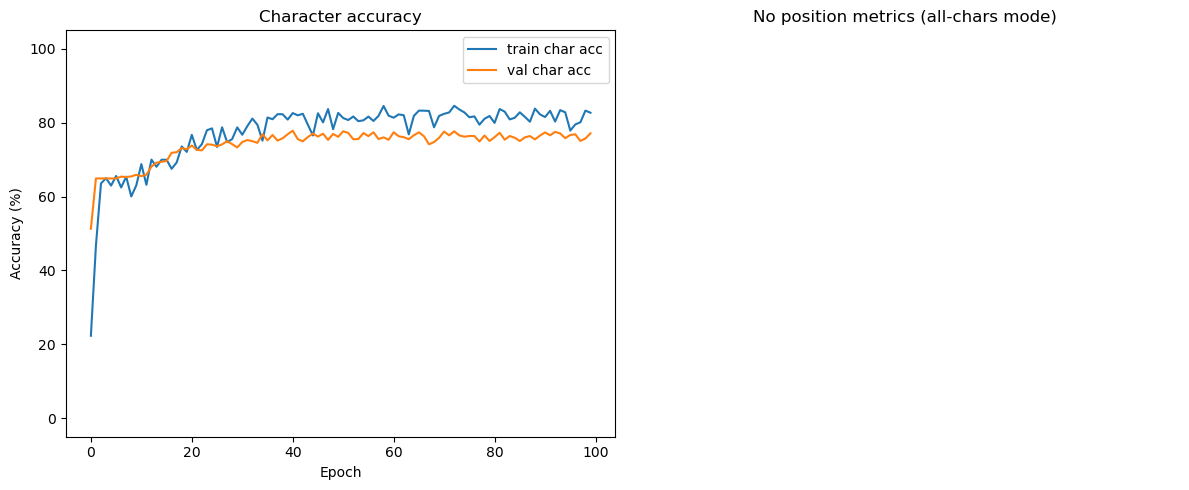

Test overall accuracy (all chars matched): 92.36%
Total test samples: 1799

加载的结果统计 (all-chars mode):
Results keys: ['train_acc_char', 'val_acc_char', 'actual_epochs']
实际训练的epoch数: 100
Final train char acc: 82.69%
Final val char acc: 77.12%
位置相关指标：N/A (all-chars mode)


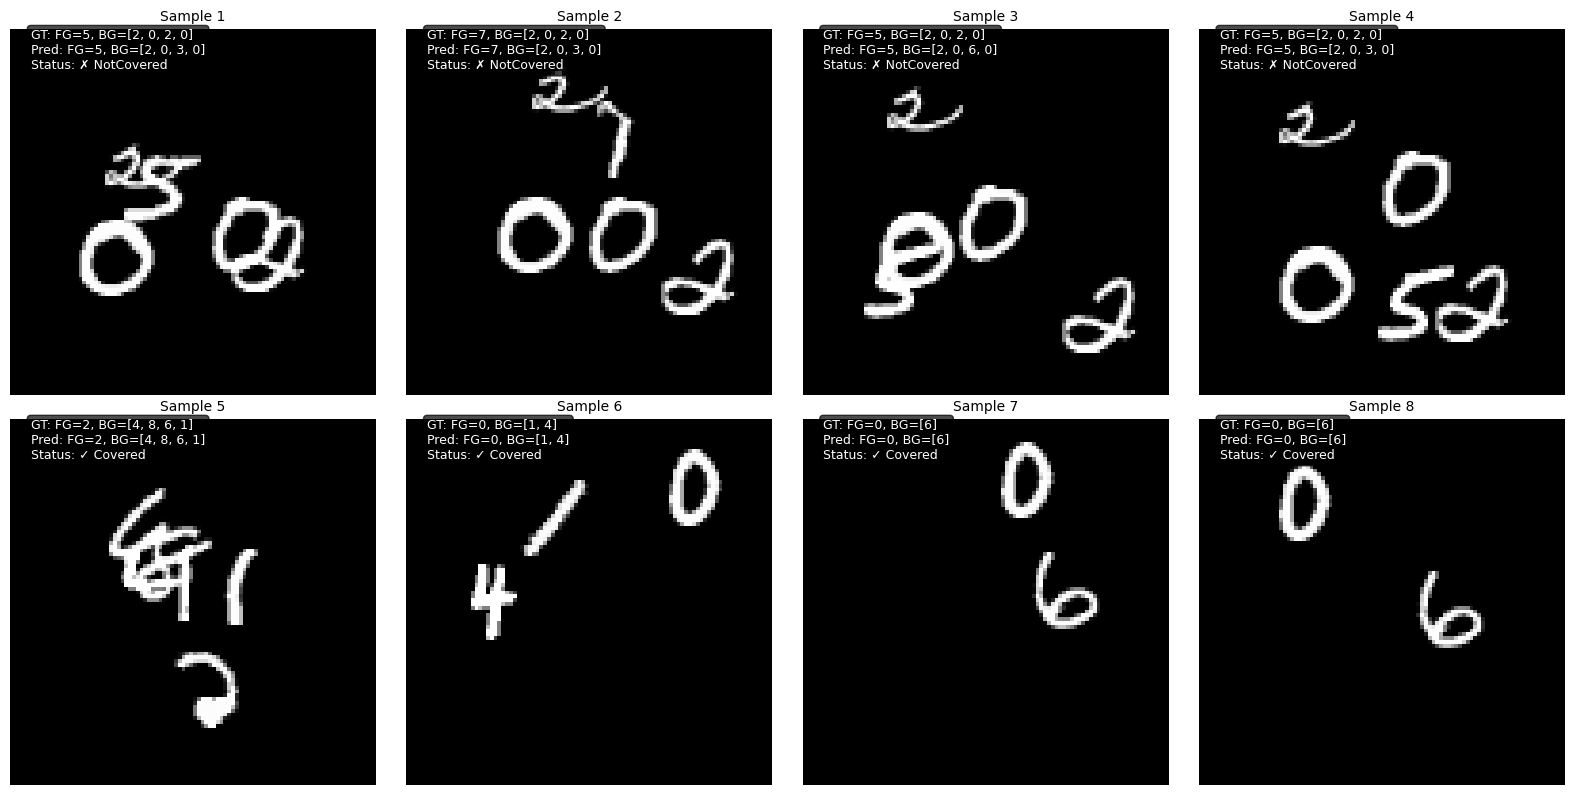

In [7]:
for hidden_size in [256]:
    results_path = f"../results/lstm_allchars_acc_h{hidden_size}_allchar.pkl"
    results_rnn, model_rnn = load_and_visualize_model(results_path, num_vis=8, model_class=LSTMConv,
                                                    hidden_size=hidden_size, show_test_results=True)

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/rnn_sector_h128.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 97.85%
Val char acc max: 50.55%
Train pos acc max: 97.68%
Val pos acc max: 82.54%


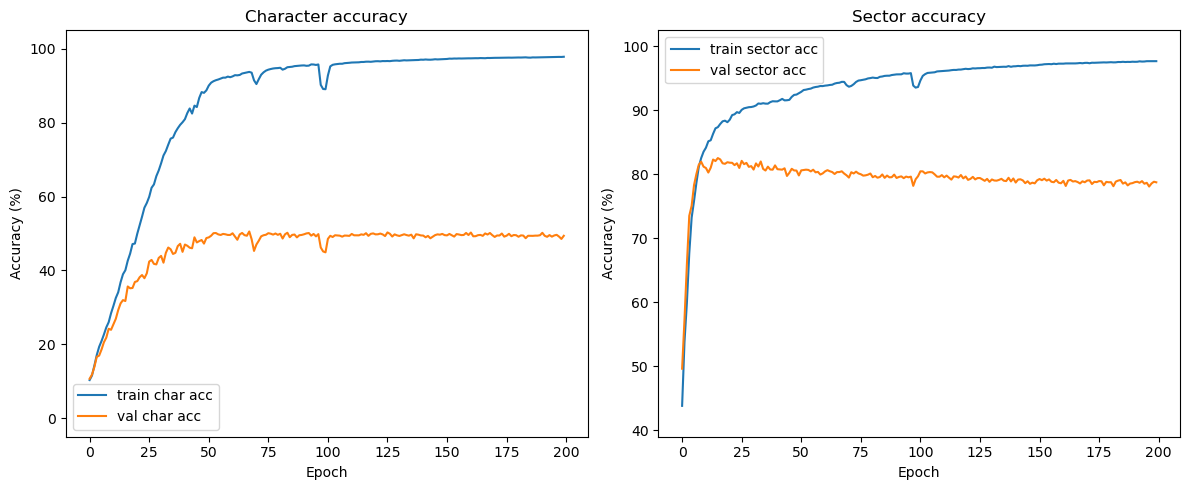

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/rnn_sector_h256.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.61%
Val char acc max: 55.40%
Train pos acc max: 99.50%
Val pos acc max: 82.60%


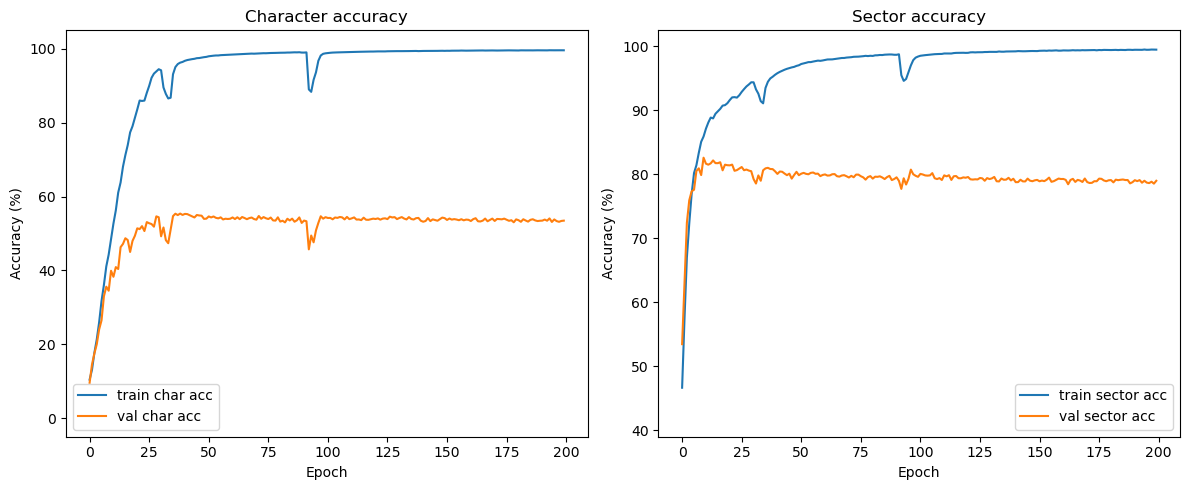

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/rnn_sector_h512.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.92%
Val char acc max: 56.90%
Train pos acc max: 99.87%
Val pos acc max: 83.60%


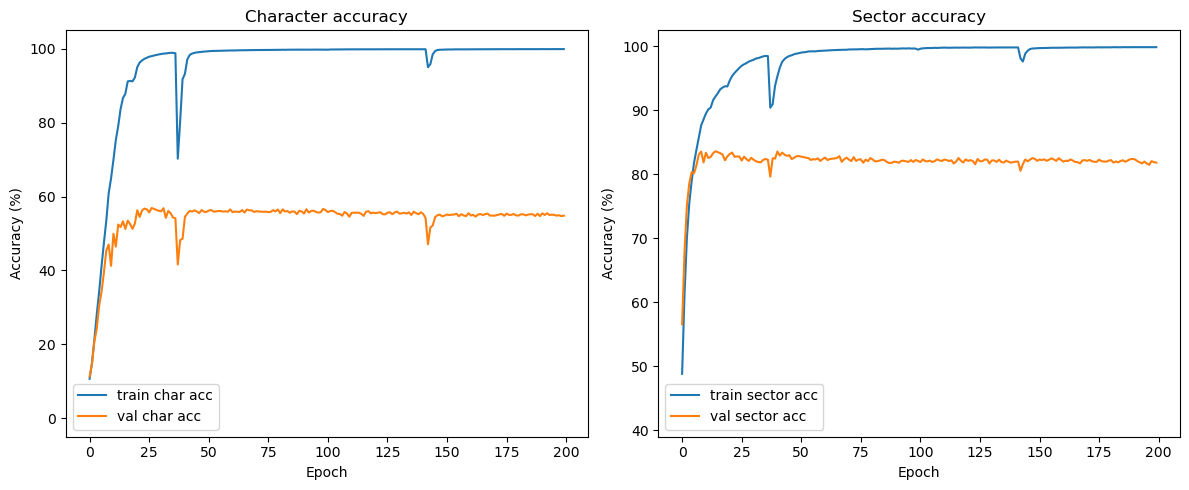

In [69]:
for hidden_size in [128, 256, 512]:
    results_path = f"/G/MIMOlab/Codes/aim3_RNN/results/rnn_sector_h{hidden_size}.pkl"
    results_rnn, model_rnn = load_and_visualize_model(results_path, num_vis=8, 
                                                    hidden_size=hidden_size, show_test_results=False)

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/lstm_sector_h128.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.82%
Val char acc max: 54.00%
Train pos acc max: 99.74%
Val pos acc max: 82.99%


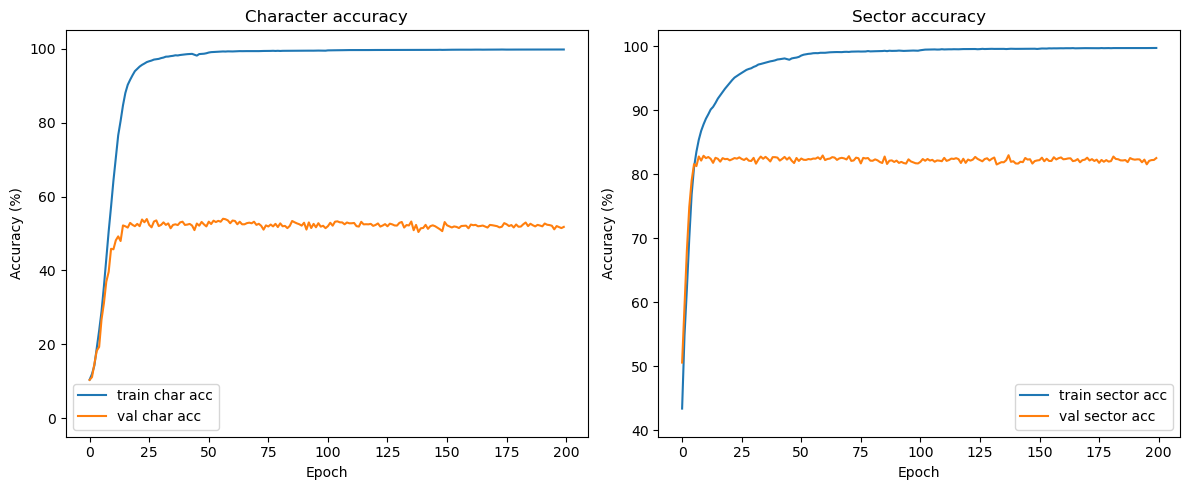

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/lstm_sector_h256.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.98%
Val char acc max: 55.84%
Train pos acc max: 99.97%
Val pos acc max: 85.84%


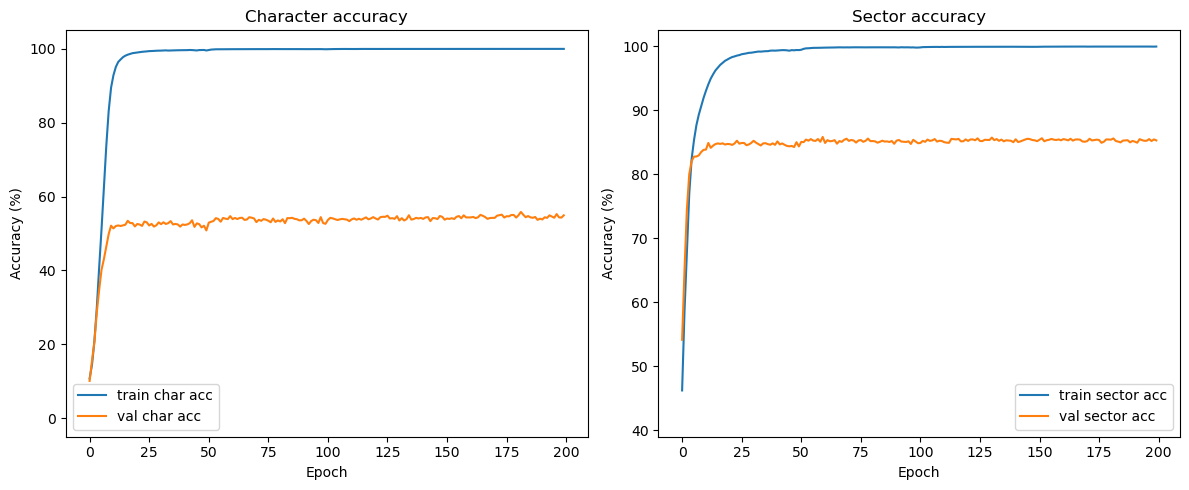

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/lstm_sector_h512.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 100.00%
Val char acc max: 56.74%
Train pos acc max: 99.99%
Val pos acc max: 84.46%


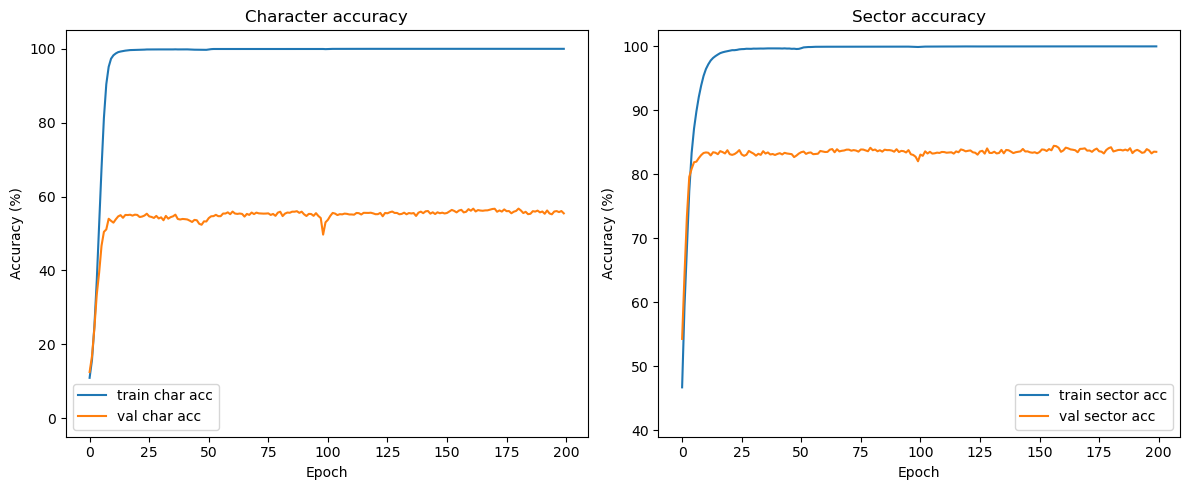

In [6]:
for hidden_size in [128, 256, 512]:
    results_path = f"/G/MIMOlab/Codes/aim3_RNN/results/lstm_sector_h{hidden_size}.pkl"
    results_rnn, model_rnn = load_and_visualize_model(results_path, num_vis=8, model_class=LSTMConv,
                                                    hidden_size=hidden_size, show_test_results=False)


检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/gru_sector_h128.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.57%
Val char acc max: 49.48%
Train pos acc max: 99.40%
Val pos acc max: 83.15%


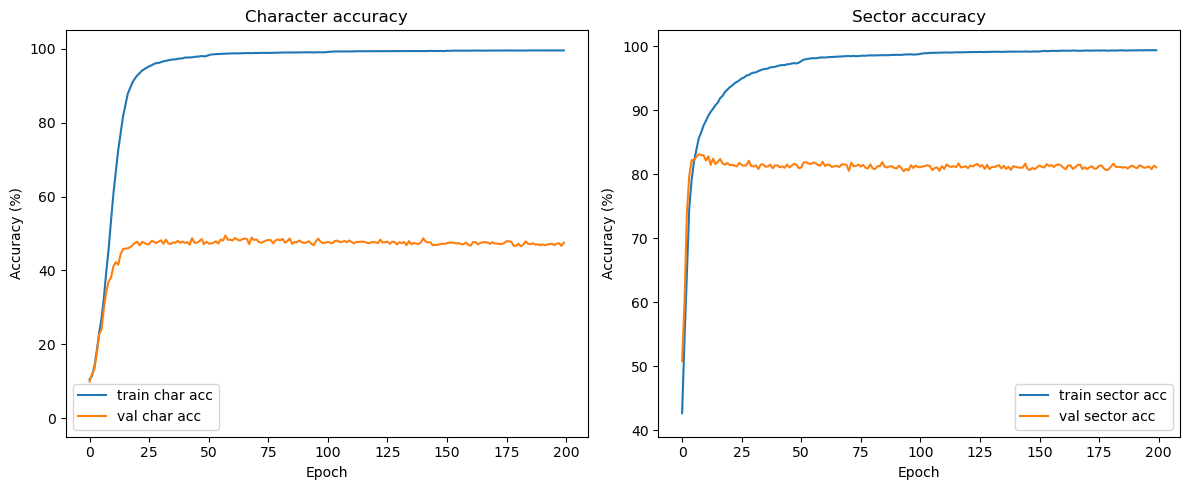

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/gru_sector_h256.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.94%
Val char acc max: 49.89%
Train pos acc max: 99.87%
Val pos acc max: 83.10%


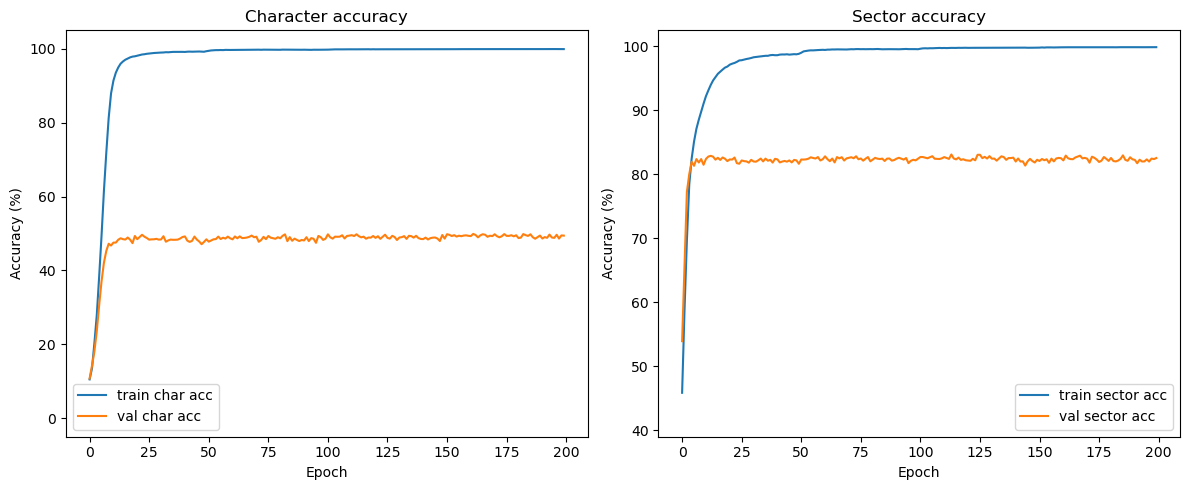

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/gru_sector_h512.pkl
检测到 checkpoint 中的 num_pos = 9
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.99%
Val char acc max: 51.92%
Train pos acc max: 99.98%
Val pos acc max: 85.44%


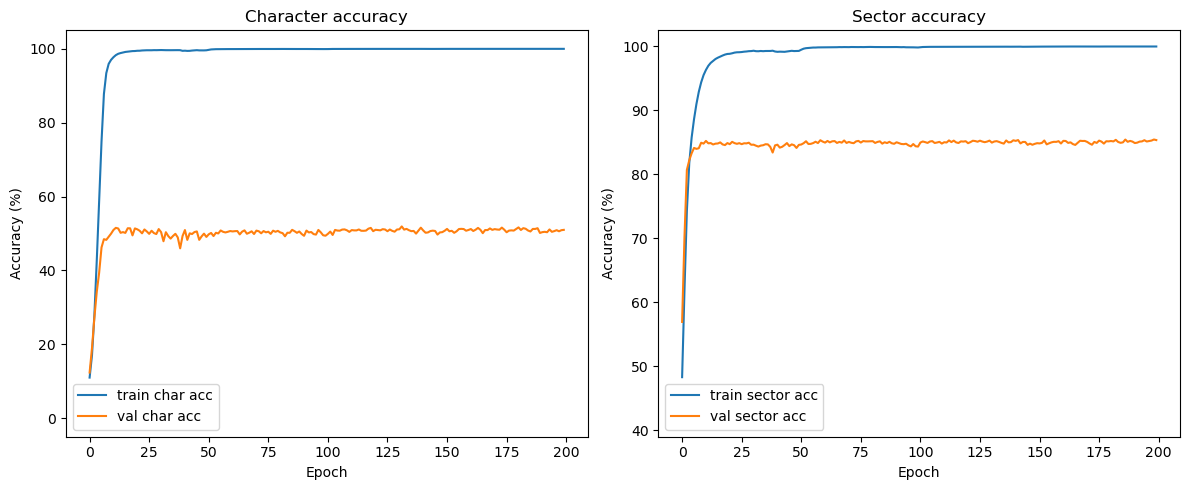

In [7]:
for hidden_size in [128, 256, 512]:
    results_path = f"/G/MIMOlab/Codes/aim3_RNN/results/gru_sector_h{hidden_size}.pkl"
    results_rnn, model_rnn = load_and_visualize_model(results_path, num_vis=8, model_class=GRUConv,
                                                    hidden_size=hidden_size, show_test_results=False)

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/gawf_sector_h128_nofb.pkl
检测到 checkpoint 中的 num_pos = 9
已过滤掉 prev_feedback（运行时状态）
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 97.70%
Val char acc max: 49.55%
Train pos acc max: 97.60%
Val pos acc max: 81.97%


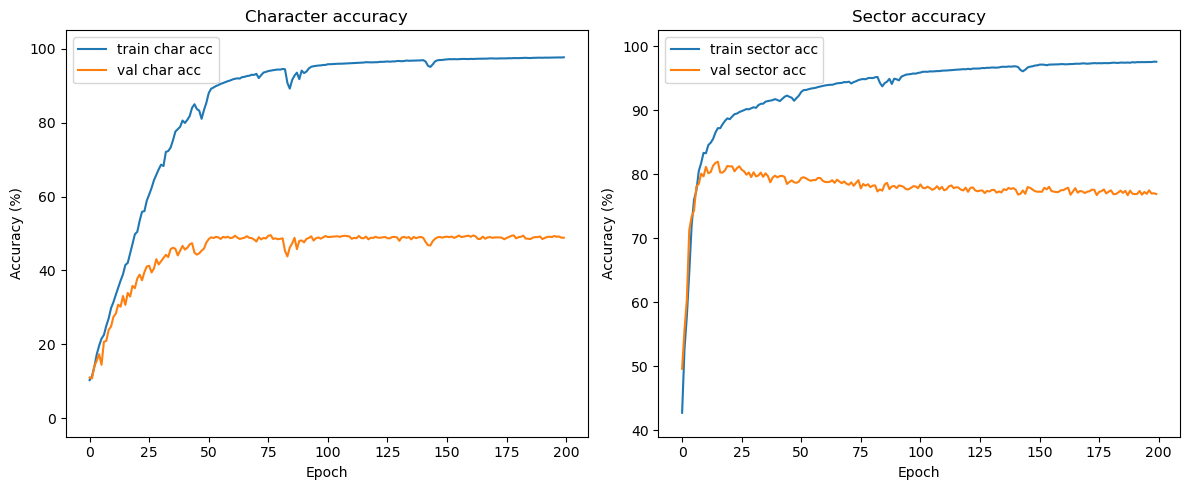

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/gawf_sector_h256_nofb.pkl
检测到 checkpoint 中的 num_pos = 9
已过滤掉 prev_feedback（运行时状态）
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.59%
Val char acc max: 54.96%
Train pos acc max: 99.46%
Val pos acc max: 82.33%


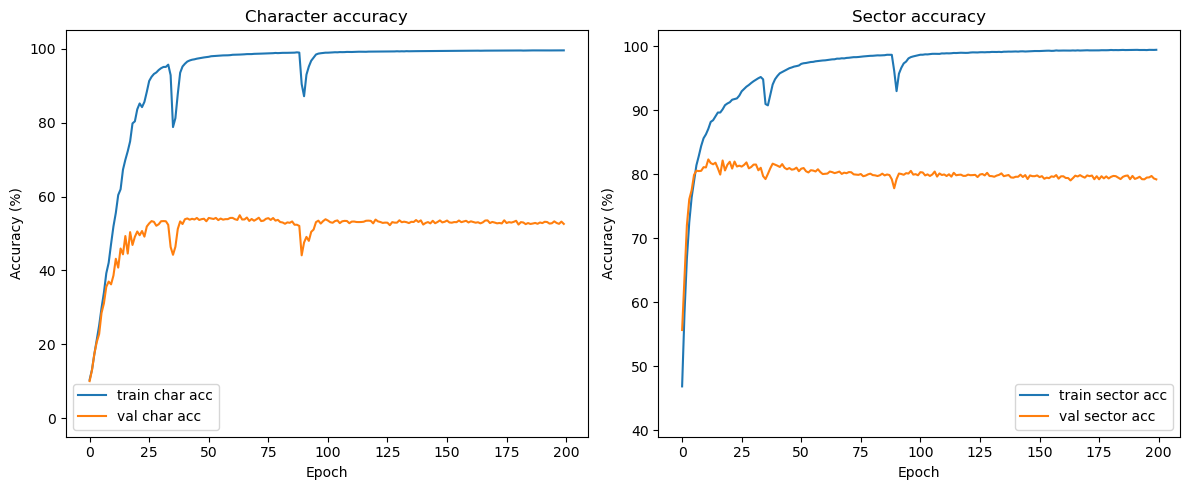

检测到模式: sector (use_sector=True)
Results loaded from: /G/MIMOlab/Codes/aim3_RNN/results/gawf_sector_h512_nofb.pkl
检测到 checkpoint 中的 num_pos = 9
已过滤掉 prev_feedback（运行时状态）
模型加载成功，num_pos = 9
实际训练的epoch数: 200
Train char acc max: 99.92%
Val char acc max: 55.63%
Train pos acc max: 99.88%
Val pos acc max: 83.10%


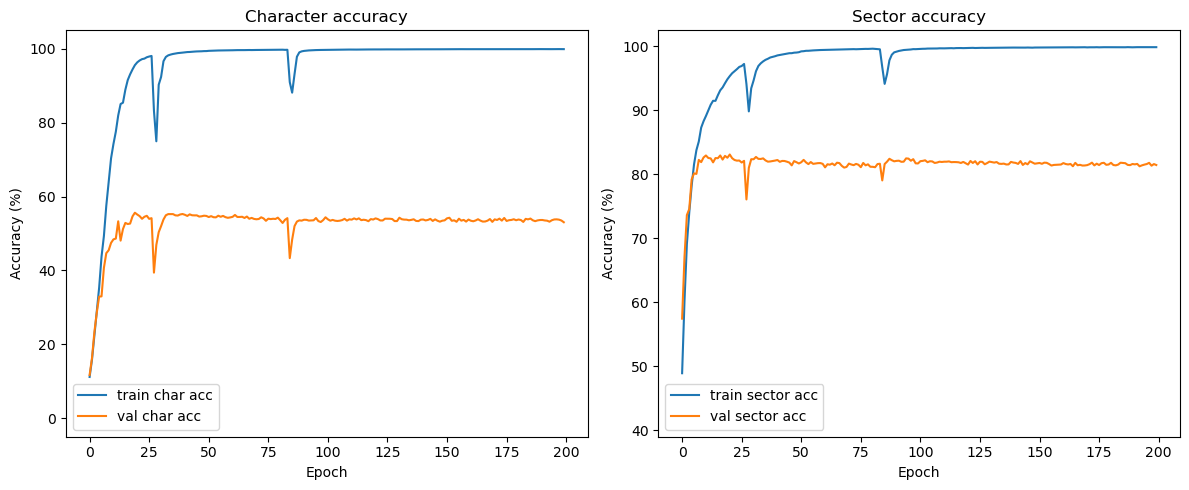

In [6]:
for hidden_size in [128, 256, 512]:
    results_path = f"/G/MIMOlab/Codes/aim3_RNN/results/gawf_sector_h{hidden_size}_nofb.pkl"
    results_rnn, model_rnn = load_and_visualize_model(results_path, num_vis=8, model_class=GaWFRNNConv,
                                                    hidden_size=hidden_size, show_test_results=False)

### Weight matrix analysis

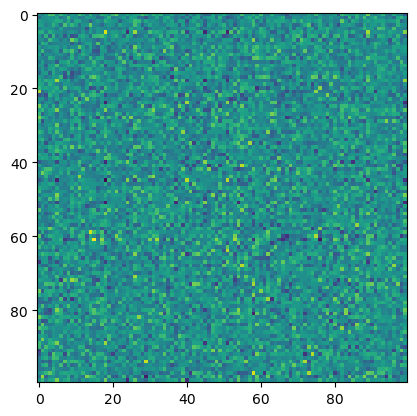

In [ ]:
params = list(mdl_rnn.rnn.parameters())[1].cpu().detach().numpy()
plt.imshow(params[:100,:100])

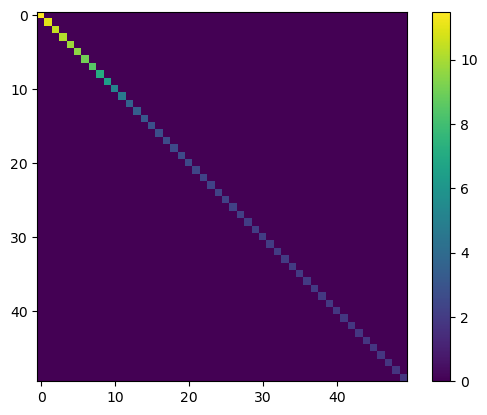

In [ ]:
U,S,V = np.linalg.svd(params, full_matrices=False)
# plt.imshow(U)
plt.imshow(np.diag(S[:50]))
# plt.imshow(V)
plt.colorbar()

## Two-layer stacked RNN

In [54]:
# Create dataset class for loading stacks of frames as multichannel images
# for use in testing the performance of recurrent models
class RNNConvStack(nn.Module):
    def __init__(self, num_classes, num_pos, kernel_size=3, device='cuda'):
        super(RNNConvStack, self).__init__()
        self.device = device
        self.conv1 = nn.Conv2d(2, 32, kernel_size=kernel_size, padding='same')
        self.MP1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.LNorm1 = nn.LayerNorm([32, 48, 48])
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.MP2 = nn.MaxPool2d(kernel_size=4, stride=4)
        self.LNorm2 = nn.LayerNorm([64, 12, 12])
        self.rnn = nn.RNN(input_size=64 * 12 * 12, hidden_size=240, 
                          num_layers=2, batch_first=True, dropout=0.5)
        self.LNormRNN = nn.LayerNorm(240)
        self.fcchar = nn.Linear(240, num_classes)
        self.fcpos = nn.Linear(240, num_pos)
        self.to(self.device)

    def encoder(self, x):
        return nn.Sequential(
            self.conv1,
            self.MP1,
            self.LNorm1,
            nn.ReLU(),
            self.conv2,
            self.MP2,
            self.LNorm2,
            nn.ReLU()
        )(x)

    def middle(self, x):
        x = self.rnn(x)[0]
        x = self.LNormRNN(x)
        x = nn.Dropout(0.5)(nn.ReLU()(x))
        return x

    def classifier(self, x):
        return self.fcchar(x), self.fcpos(x)

    def forward(self, x):
        x = x.to(self.device)

        batch_size, frame_num, channels, height, width = x.size()

        # resize to process each frame individually
        x = x.view(batch_size * frame_num, channels, height, width)

        # apply CNN encoder
        x = self.encoder(x)
        
        # reshape back to batches of stacks of frames and flatten each image
        x = x.view(batch_size, frame_num, -1)

        # apply RNN
        x = self.middle(x)

        # apply classification heads
        char_out, pos_out = self.classifier(x)
        return char_out, pos_out

In [ ]:
stim_train_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-train.npy"
label_train_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-train.tsv"
stims_train = np.load(stim_train_path, allow_pickle=True)
lbls_train = pd.read_csv(label_train_path, sep="\t", index_col=0)

stim_val_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-validation.npy"
label_val_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-validation.tsv"
stims_val = np.load(stim_val_path, allow_pickle=True)
lbls_val = pd.read_csv(label_val_path, sep="\t", index_col=0)


train_ds = MC_RNN_Dataset(stims_train, lbls_train)
val_ds = MC_RNN_Dataset(stims_val, lbls_val)
mdl_rnn = RNNConvStack(num_classes=10, num_pos=2, kernel_size=5)
print(f"RNN model parameter count: {model_param_count(mdl_rnn)}")
results_rnn = network_train(mdl_rnn, train_ds, val_ds, num_epochs=50, loss_weights=[1.0, 0.001])

RNN model parameter count: 2574988
Epoch 1/50 - Train (char, pos): (10.17%, 1044.88 pix^2)  Validation (char, pos): (9.93%, 437.34 pix^2)
Epoch 2/50 - Train (char, pos): (10.33%, 381.28 pix^2)  Validation (char, pos): (10.55%, 333.24 pix^2)
Epoch 3/50 - Train (char, pos): (10.48%, 261.57 pix^2)  Validation (char, pos): (11.30%, 184.40 pix^2)
Epoch 4/50 - Train (char, pos): (10.31%, 189.89 pix^2)  Validation (char, pos): (9.89%, 159.15 pix^2)
Epoch 5/50 - Train (char, pos): (13.64%, 167.69 pix^2)  Validation (char, pos): (17.55%, 156.85 pix^2)
Epoch 6/50 - Train (char, pos): (19.28%, 162.05 pix^2)  Validation (char, pos): (20.49%, 145.13 pix^2)
Epoch 7/50 - Train (char, pos): (21.94%, 151.61 pix^2)  Validation (char, pos): (20.92%, 136.54 pix^2)
Epoch 8/50 - Train (char, pos): (24.22%, 151.23 pix^2)  Validation (char, pos): (23.73%, 138.65 pix^2)
Epoch 9/50 - Train (char, pos): (27.50%, 141.90 pix^2)  Validation (char, pos): (28.30%, 133.79 pix^2)
Epoch 10/50 - Train (char, pos): (31.24

## Split RNN, split classification
RNNs are separated into distinct classification channels

In [61]:
# Create dataset class for loading stacks of frames as multichannel images
# for use in testing the performance of recurrent models
class RNNConvSplitDisc(nn.Module):
    def __init__(self, num_classes, num_pos, kernel_size=3, device='cuda'):
        super(RNNConvSplitDisc, self).__init__()
        self.device = device
        self.conv1 = nn.Conv2d(2, 32, kernel_size=kernel_size, padding='same')
        self.MP1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.LNorm1 = nn.LayerNorm([32, 48, 48])
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.MP2 = nn.MaxPool2d(kernel_size=4, stride=4)
        self.LNorm2 = nn.LayerNorm([64, 12, 12])
        self.rnnchar = nn.RNN(input_size=64 * 12 * 12, hidden_size=128, 
                          num_layers=1, batch_first=True)
        self.rnnpos = nn.RNN(input_size=64 * 12 * 12, hidden_size=128, 
                          num_layers=1, batch_first=True)
        self.LNormRNNPos = nn.LayerNorm(128)
        self.LNormRNNChar = nn.LayerNorm(128)
        self.fcchar = nn.Linear(128, num_classes)
        self.fcpos = nn.Linear(128, num_pos)
        self.to(self.device)

    def encoder(self, x):
        return nn.Sequential(
            self.conv1,
            self.MP1,
            self.LNorm1,
            nn.ReLU(),
            self.conv2,
            self.MP2,
            self.LNorm2,
            nn.ReLU()
        )(x)

    def middle(self, x):
        xchar = self.rnnchar(x)[0]
        xpos = self.rnnpos(x)[0]
        xchar = self.LNormRNNChar(xchar)
        xpos = self.LNormRNNPos(xpos)
        xchar = nn.Dropout(0.5)(nn.ReLU()(xchar))
        xpos = nn.Dropout(0.5)(nn.ReLU()(xpos))
        return xchar, xpos

    def classifier(self, xc, xp):
        return self.fcchar(xc), self.fcpos(xp)

    def forward(self, x):
        x = x.to(self.device)

        batch_size, frame_num, channels, height, width = x.size()

        # resize to process each frame individually
        x = x.view(batch_size * frame_num, channels, height, width)

        # apply CNN encoder
        x = self.encoder(x)
        
        # reshape back to batches of stacks of frames and flatten each image
        x = x.view(batch_size, frame_num, -1)

        # apply RNN
        xc, xp = self.middle(x)

        # apply classification heads
        char_out, pos_out = self.classifier(xc, xp)
        return char_out, pos_out

In [ ]:
stim_train_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-train.npy"
label_train_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-train.tsv"
stims_train = np.load(stim_train_path, allow_pickle=True)
lbls_train = pd.read_csv(label_train_path, sep="\t", index_col=0)

stim_val_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-validation.npy"
label_val_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-validation.tsv"
stims_val = np.load(stim_val_path, allow_pickle=True)
lbls_val = pd.read_csv(label_val_path, sep="\t", index_col=0)


train_ds = MC_RNN_Dataset(stims_train, lbls_train)
val_ds = MC_RNN_Dataset(stims_val, lbls_val)
mdl_rnn = RNNConvSplitDisc(num_classes=10, num_pos=2, kernel_size=5)
print(f"RNN model parameter count: {model_param_count(mdl_rnn)}")
results_rnn = network_train(mdl_rnn, train_ds, val_ds, num_epochs=50, loss_weights=[1.0, 0.001])

RNN model parameter count: 2580652
Epoch 1/50 - Train (char, pos): (10.36%, 1399.52 pix^2)  Validation (char, pos): (10.49%, 614.85 pix^2)
Epoch 2/50 - Train (char, pos): (11.01%, 461.18 pix^2)  Validation (char, pos): (10.44%, 428.46 pix^2)
Epoch 3/50 - Train (char, pos): (12.67%, 381.31 pix^2)  Validation (char, pos): (13.81%, 339.84 pix^2)
Epoch 4/50 - Train (char, pos): (18.04%, 295.52 pix^2)  Validation (char, pos): (16.14%, 271.65 pix^2)
Epoch 5/50 - Train (char, pos): (20.53%, 246.13 pix^2)  Validation (char, pos): (21.47%, 216.93 pix^2)
Epoch 6/50 - Train (char, pos): (25.78%, 206.18 pix^2)  Validation (char, pos): (26.76%, 189.22 pix^2)
Epoch 7/50 - Train (char, pos): (29.89%, 184.58 pix^2)  Validation (char, pos): (29.54%, 177.54 pix^2)
Epoch 8/50 - Train (char, pos): (35.29%, 168.03 pix^2)  Validation (char, pos): (34.12%, 161.81 pix^2)
Epoch 9/50 - Train (char, pos): (41.45%, 154.15 pix^2)  Validation (char, pos): (35.79%, 165.53 pix^2)
Epoch 10/50 - Train (char, pos): (46.

KeyboardInterrupt: 

## Split RNN, shared classification
One for character, the other for position

In [9]:
# Create dataset class for loading stacks of frames as multichannel images
# for use in testing the performance of recurrent models
class RNNConvSplit(nn.Module):
    def __init__(self, num_classes, num_pos, kernel_size=3, device='cuda'):
        super(RNNConvSplit, self).__init__()
        self.device = device
        self.conv1 = nn.Conv2d(2, 32, kernel_size=kernel_size, padding='same')
        self.MP1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.LNorm1 = nn.LayerNorm([32, 48, 48])
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.MP2 = nn.MaxPool2d(kernel_size=4, stride=4)
        self.LNorm2 = nn.LayerNorm([64, 12, 12])
        self.rnnchar = nn.RNN(input_size=64 * 12 * 12, hidden_size=128, 
                          num_layers=1, batch_first=True)
        self.rnnpos = nn.RNN(input_size=64 * 12 * 12, hidden_size=128, 
                          num_layers=1, batch_first=True)
        self.LNormRNN = nn.LayerNorm(256)
        self.fcchar = nn.Linear(256, num_classes)
        self.fcpos = nn.Linear(256, num_pos)
        self.to(self.device)

    def encoder(self, x):
        return nn.Sequential(
            self.conv1,
            self.MP1,
            self.LNorm1,
            nn.ReLU(),
            self.conv2,
            self.MP2,
            self.LNorm2,
            nn.ReLU()
        )(x)

    def middle(self, x):
        xchar = self.rnnchar(x)[0]
        xpos = self.rnnpos(x)[0]
        x = torch.cat((xchar, xpos), dim=2)
        x = self.LNormRNN(x)
        x = nn.Dropout(0.5)(nn.ReLU()(x))
        return x

    def classifier(self, x):
        return self.fcchar(x), self.fcpos(x)

    def forward(self, x):
        x = x.to(self.device)

        batch_size, frame_num, channels, height, width = x.size()

        # resize to process each frame individually
        x = x.view(batch_size * frame_num, channels, height, width)

        # apply CNN encoder
        x = self.encoder(x)
        
        # reshape back to batches of stacks of frames and flatten each image
        x = x.view(batch_size, frame_num, -1)

        # apply RNN
        x = self.middle(x)

        # apply classification heads
        char_out, pos_out = self.classifier(x)
        return char_out, pos_out

In [ ]:
stim_train_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-train.npy"
label_train_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-train.tsv"
stims_train = np.load(stim_train_path, allow_pickle=True)
lbls_train = pd.read_csv(label_train_path, sep="\t", index_col=0)

stim_val_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-validation.npy"
label_val_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-validation.tsv"
stims_val = np.load(stim_val_path, allow_pickle=True)
lbls_val = pd.read_csv(label_val_path, sep="\t", index_col=0)


train_ds = MC_RNN_Dataset(stims_train, lbls_train)
val_ds = MC_RNN_Dataset(stims_val, lbls_val)
mdl_rnn = RNNConvSplit(num_classes=10, num_pos=2, kernel_size=5)
results_rnn = network_train(mdl_rnn, train_ds, val_ds, num_epochs=50, loss_weights=[1.0, 0.001])

Epoch 1/50 - Train (char, pos): (10.28%, 1007.72 pix^2)  Validation (char, pos): (9.53%, 408.06 pix^2)
Epoch 2/50 - Train (char, pos): (12.10%, 356.80 pix^2)  Validation (char, pos): (14.09%, 339.01 pix^2)
Epoch 3/50 - Train (char, pos): (18.56%, 299.95 pix^2)  Validation (char, pos): (17.79%, 285.08 pix^2)
Epoch 4/50 - Train (char, pos): (24.43%, 266.72 pix^2)  Validation (char, pos): (25.65%, 258.40 pix^2)
Epoch 5/50 - Train (char, pos): (32.65%, 246.95 pix^2)  Validation (char, pos): (32.47%, 236.49 pix^2)
Epoch 6/50 - Train (char, pos): (41.55%, 226.74 pix^2)  Validation (char, pos): (39.48%, 220.59 pix^2)
Epoch 7/50 - Train (char, pos): (49.09%, 209.48 pix^2)  Validation (char, pos): (42.83%, 212.25 pix^2)
Epoch 8/50 - Train (char, pos): (56.56%, 194.53 pix^2)  Validation (char, pos): (45.95%, 202.17 pix^2)
Epoch 9/50 - Train (char, pos): (62.79%, 186.15 pix^2)  Validation (char, pos): (47.67%, 199.44 pix^2)
Epoch 10/50 - Train (char, pos): (68.38%, 178.92 pix^2)  Validation (char

## Shared layer 1 RNN, split at layer 2

In [11]:
# Create dataset class for loading stacks of frames as multichannel images
# for use in testing the performance of recurrent models
class RNNConvShareSplit(nn.Module):
    def __init__(self, num_classes, num_pos, kernel_size=3, device='cuda'):
        super(RNNConvShareSplit, self).__init__()
        self.device = device
        self.conv1 = nn.Conv2d(2, 32, kernel_size=kernel_size, padding='same')
        self.MP1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.LNorm1 = nn.LayerNorm([32, 48, 48])
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.MP2 = nn.MaxPool2d(kernel_size=4, stride=4)
        self.LNorm2 = nn.LayerNorm([64, 12, 12])
        self.rnnshare = nn.RNN(input_size=64 * 12 * 12, hidden_size=128, 
                          num_layers=1, batch_first=True)
        self.rnnchar = nn.RNN(input_size=128, hidden_size=64, 
                          num_layers=1, batch_first=True)
        self.rnnpos = nn.RNN(input_size=128, hidden_size=64, 
                          num_layers=1, batch_first=True)
        self.LNormRNN = nn.LayerNorm(128)
        self.fcchar = nn.Linear(128, num_classes)
        self.fcpos = nn.Linear(128, num_pos)
        self.to(self.device)

    def encoder(self, x):
        return nn.Sequential(
            self.conv1,
            self.MP1,
            self.LNorm1,
            nn.ReLU(),
            self.conv2,
            self.MP2,
            self.LNorm2,
            nn.ReLU()
        )(x)

    def middle(self, x):
        x = self.rnnshare(x)[0]
        x = nn.Dropout(0.5)(nn.ReLU()(x))
        xchar = self.rnnchar(x)[0]
        xpos = self.rnnpos(x)[0]
        x = torch.cat((xchar, xpos), dim=2)
        x = self.LNormRNN(x)
        x = nn.Dropout(0.5)(nn.ReLU()(x))
        return x

    def classifier(self, x):
        return self.fcchar(x), self.fcpos(x)

    def forward(self, x):
        x = x.to(self.device)

        batch_size, frame_num, channels, height, width = x.size()

        # resize to process each frame individually
        x = x.view(batch_size * frame_num, channels, height, width)

        # apply CNN encoder
        x = self.encoder(x)
        
        # reshape back to batches of stacks of frames and flatten each image
        x = x.view(batch_size, frame_num, -1)

        # apply RNN
        x = self.middle(x)

        # apply classification heads
        char_out, pos_out = self.classifier(x)
        return char_out, pos_out

In [ ]:
stim_train_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-train.npy"
label_train_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-train.tsv"
stims_train = np.load(stim_train_path, allow_pickle=True)
lbls_train = pd.read_csv(label_train_path, sep="\t", index_col=0)

stim_val_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-validation.npy"
label_val_path = "/G/MIMOlab/Codes/aim3_RNN/stimuli/stimulus_reg-validation.tsv"
stims_val = np.load(stim_val_path, allow_pickle=True)
lbls_val = pd.read_csv(label_val_path, sep="\t", index_col=0)


train_ds = MC_RNN_Dataset(stims_train, lbls_train)
val_ds = MC_RNN_Dataset(stims_val, lbls_val)
mdl_rnn = RNNConvShareSplit(num_classes=10, num_pos=2, kernel_size=5)
results_rnn = network_train(mdl_rnn, train_ds, val_ds, num_epochs=50, loss_weights=[1.0, 0.001])

Epoch 1/50 - Train (char, pos): (10.13%, 1466.85 pix^2)  Validation (char, pos): (10.29%, 610.03 pix^2)
Epoch 2/50 - Train (char, pos): (10.20%, 464.04 pix^2)  Validation (char, pos): (11.91%, 438.14 pix^2)
Epoch 3/50 - Train (char, pos): (10.14%, 380.08 pix^2)  Validation (char, pos): (9.88%, 327.60 pix^2)
Epoch 4/50 - Train (char, pos): (10.27%, 276.87 pix^2)  Validation (char, pos): (9.66%, 240.29 pix^2)
Epoch 5/50 - Train (char, pos): (10.85%, 220.14 pix^2)  Validation (char, pos): (10.60%, 201.26 pix^2)
Epoch 6/50 - Train (char, pos): (10.73%, 196.96 pix^2)  Validation (char, pos): (11.34%, 179.14 pix^2)
Epoch 7/50 - Train (char, pos): (11.32%, 182.92 pix^2)  Validation (char, pos): (11.23%, 171.28 pix^2)
Epoch 8/50 - Train (char, pos): (15.11%, 189.85 pix^2)  Validation (char, pos): (16.30%, 188.08 pix^2)
Epoch 9/50 - Train (char, pos): (18.86%, 197.10 pix^2)  Validation (char, pos): (15.61%, 203.26 pix^2)
Epoch 10/50 - Train (char, pos): (21.10%, 191.42 pix^2)  Validation (char,